## Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
okc_data = pd.read_csv('../data/raw/okc_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')
sas_data = pd.read_csv('../data/raw/sas_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')
nyk_data = pd.read_csv('../data/raw/nyk_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')
cle_data = pd.read_csv('../data/raw/cle_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')

## Weighted Ratings

In [13]:
def weighted_mean(df, is_home, col):
    season = df.loc[(df['IS_HOME'] == is_home) & (~df['PLAYOFF']), col]
    playoff = df.loc[(df['IS_HOME'] == is_home) & (df['PLAYOFF']), col]
    
    n_season = len(season)
    n_playoff = len(playoff)
    
    total = n_season + n_playoff
    if total == 0:
        return np.nan, 0, 0
    return (season.sum() + playoff.sum()) / total, n_season, n_playoff    

## Signals 
1. **Pace-adjusted efficiency** — ORTG/DRTG per 100 possessions removes tempo distortion
2. **Exponential recency weighting** — recent games count more (decay=0.97 per game)
3. **Playoff upweighting** — playoff games weighted 3× over regular season
4. **Within-series adjustment** — games already played in this series anchor the lambda


In [14]:
def add_recency_weights(df, decay=0.97, playoff_multiplier=2.0):
    df = df.sort_index().copy()
    n = len(df)
    decay_w = np.array([decay ** (n - 1 - i) for i in range(n)])
    playoff_w = np.where(df['PLAYOFF'], playoff_multiplier, 1.0)
    df['weight'] = decay_w * playoff_w
    return df


def build_ratings(df, decay=0.97, playoff_multiplier=3.0):
    df = add_recency_weights(df, decay=decay, playoff_multiplier=playoff_multiplier)
    df = df.copy()
    df['ORTG'] = df['PTS'] / df['PACE'] * 100
    df['DRTG'] = df['POINTS_AGAINST'] / df['PACE'] * 100

    ratings = {}
    for location, is_home in [('home', True), ('away', False)]:
        mask = df['IS_HOME'] == (1 if is_home else 0)
        subset = df[mask]
        if len(subset) == 0:
            ratings[f'{location}_ortg'] = np.nan
            ratings[f'{location}_drtg'] = np.nan
            continue
        w = subset['weight']
        total_w = w.sum()
        ratings[f'{location}_ortg'] = (subset['ORTG'] * w).sum() / total_w
        ratings[f'{location}_drtg'] = (subset['DRTG'] * w).sum() / total_w
        ratings[f'{location}_n']    = len(subset)
    return ratings


def expected_points(home_ratings, away_ratings, avg_pace):
    lam_home = (home_ratings['home_ortg'] + away_ratings['away_drtg']) / 2 * avg_pace / 100
    lam_away = (away_ratings['away_ortg'] + home_ratings['home_drtg']) / 2 * avg_pace / 100
    return lam_home, lam_away


def within_series_adjust(lam_home_base, lam_away_base, series_scores,
                          base_sample=15, series_weight=2.0):
    if not series_scores:
        return lam_home_base, lam_away_base
    k = len(series_scores)
    obs_home = np.mean([s[0] for s in series_scores])
    obs_away = np.mean([s[1] for s in series_scores])
    eff = k * series_weight
    total = base_sample + eff
    return (lam_home_base * base_sample + obs_home * eff) / total, \
           (lam_away_base * base_sample + obs_away * eff) / total


def make_home_schedule(wins_higher, wins_lower):
    """NBA 2-2-1-1-1 format. Returns remaining games from team1 (higher seed) perspective."""
    full = [True, True, False, False, True, False, True]
    return full[wins_higher + wins_lower:]


def compute_series_lambdas(t1_ratings, t2_ratings, avg_pace,
                            t1_home_scores=None, t2_home_scores=None):
    """
    t1 = higher seed (has home court for games 1,2,5,7).
    Returns lambdas dict keyed by 'team1_home' and 'team1_away'.
    Each value is (lam_t1, lam_t2) for that configuration.
    """
    lam1_h, lam2_h = expected_points(t1_ratings, t2_ratings, avg_pace)
    lam2_home, lam1_away = expected_points(t2_ratings, t1_ratings, avg_pace)

    lam1_h, lam2_h = within_series_adjust(lam1_h, lam2_h, t1_home_scores or [])
    # For t2-home games: series_scores are from t2's perspective as home — swap to get (t1_away, t2_home)
    t2_home_swapped = [(s[1], s[0]) for s in (t2_home_scores or [])]
    lam2_home, lam1_away = within_series_adjust(lam2_home, lam1_away, t2_home_swapped)

    return {
        'team1_home': (lam1_h,   lam2_h),
        'team1_away': (lam1_away, lam2_home),
    }


# Build v2 ratings for all four teams
okc_ratings = build_ratings(okc_data)
sas_ratings = build_ratings(sas_data)
nyk_ratings = build_ratings(nyk_data)
cle_ratings = build_ratings(cle_data)

print("OKC v2:", {k: round(v, 2) for k, v in okc_ratings.items() if 'ortg' in k or 'drtg' in k})
print("SAS v2:", {k: round(v, 2) for k, v in sas_ratings.items() if 'ortg' in k or 'drtg' in k})
print("NYK v2:", {k: round(v, 2) for k, v in nyk_ratings.items() if 'ortg' in k or 'drtg' in k})
print("CLE v2:", {k: round(v, 2) for k, v in cle_ratings.items() if 'ortg' in k or 'drtg' in k})

OKC v2: {'home_ortg': np.float64(117.34), 'home_drtg': np.float64(105.11), 'away_ortg': np.float64(121.43), 'away_drtg': np.float64(110.3)}
SAS v2: {'home_ortg': np.float64(116.44), 'home_drtg': np.float64(103.39), 'away_ortg': np.float64(116.45), 'away_drtg': np.float64(107.31)}
NYK v2: {'home_ortg': np.float64(118.78), 'home_drtg': np.float64(104.82), 'away_ortg': np.float64(119.83), 'away_drtg': np.float64(106.2)}
CLE v2: {'home_ortg': np.float64(116.42), 'home_drtg': np.float64(111.92), 'away_ortg': np.float64(109.55), 'away_drtg': np.float64(109.84)}


## Expected Points

$\lambda$ = average of team's own location-split offense and opponent's location-split defense allowed, scaled by pace.

$$\lambda_{\text{home}} = \frac{\text{ORTG}_{\text{home}} + \text{DRTG allowed}_{\text{away}}}{2} \times \frac{\text{pace}}{100}$$

$$\lambda_{\text{away}} = \frac{\text{ORTG}_{\text{away}} + \text{DRTG allowed}_{\text{home}}}{2} \times \frac{\text{pace}}{100}$$

- **ORTG** — weighted offensive efficiency (pts per 100 possessions) from that location
- **DRTG allowed** — weighted defensive efficiency allowed from that location
- **Averaging** balances offensive and defensive signal; neither alone is unbiased
- **× pace / 100** converts per-100-possession ratings to expected points per game

$\lambda$ feeds directly into the Poisson scorer in `simulate_game`.

## Game and Series Simulation

In [33]:
def simulate_game(team1_is_home, lambdas, rng):
    """
    Draw Poisson scores for one game. Re-draws on ties.
    lambdas dict has keys 'team1_home' and 'team1_away', each (lam1, lam2).
    Returns (team1_pts, team2_pts).
    """
    lam1, lam2 = lambdas['team1_home' if team1_is_home else 'team1_away']
    while True:
        p1 = rng.poisson(lam1)
        p2 = rng.poisson(lam2)
        if p1 != p2:
            return p1, p2

In [34]:
def simulate_series(lambdas, t1_wins_start, t2_wins_start,
                    home_schedule, t1_name, t2_name, rng):
    """
    Simulate remaining games in a series.
    home_schedule: list of bool — True when team1 (higher seed) is at home.
    Returns dict with winner, win counts, games_played, and outcome string.
    """
    t1w, t2w = t1_wins_start, t2_wins_start
    games_played = t1_wins_start + t2_wins_start

    for is_home in home_schedule:
        if t1w == 4 or t2w == 4:
            break
        p1, p2 = simulate_game(is_home, lambdas, rng)
        if p1 > p2:
            t1w += 1
        else:
            t2w += 1
        games_played += 1

    winner = t1_name if t1w == 4 else t2_name
    top, bot = max(t1w, t2w), min(t1w, t2w)
    return {
        'winner':           winner,
        f'{t1_name}_wins':  t1w,
        f'{t2_name}_wins':  t2w,
        'games_played':     games_played,
        'outcome':          f'{winner} {top}-{bot}',
    }

## Monte Carlo Simulation — WCF, ECF, and NBA Finals

In [ ]:
N_SIMS = 10_000
rng    = np.random.default_rng(42)

# ── WCF: OKC (higher seed) vs SAS, series tied 1-1 ──────────────────────────
# Games 1 & 2 both at OKC. OKC: 115 / 122. SAS: 122 / 113.
wcf_pace = (okc_data[okc_data['PLAYOFF']]['PACE'].mean() +
            sas_data[sas_data['PLAYOFF']]['PACE'].mean()) / 2

wcf_lambdas  = compute_series_lambdas(
    okc_ratings, sas_ratings, wcf_pace,
    t1_home_scores=[(115, 122), (122, 113)],
    t2_home_scores=[],
)
wcf_schedule = make_home_schedule(1, 1)   # Games 3-7 remaining

wcf_results = [
    simulate_series(wcf_lambdas, 1, 1, wcf_schedule, 'OKC', 'SAS', rng)
    for _ in range(N_SIMS)
]
wcf_df = pd.DataFrame(wcf_results)

# ── ECF: NYK (higher seed) vs CLE, NYK leads 1-0 ────────────────────────────
# Game 1 at NYK. NYK 115, CLE 104.
ecf_pace = (nyk_data[nyk_data['PLAYOFF']]['PACE'].mean() +
            cle_data[cle_data['PLAYOFF']]['PACE'].mean()) / 2

ecf_lambdas  = compute_series_lambdas(
    nyk_ratings, cle_ratings, ecf_pace,
    t1_home_scores=[(115, 104)],
    t2_home_scores=[],
)
ecf_schedule = make_home_schedule(1, 0)   # Games 2-7 remaining

ecf_results = [
    simulate_series(ecf_lambdas, 1, 0, ecf_schedule, 'NYK', 'CLE', rng)
    for _ in range(N_SIMS)
]
ecf_df = pd.DataFrame(ecf_results)

p_okc = (wcf_df['winner'] == 'OKC').mean()
p_sas = 1 - p_okc
p_nyk = (ecf_df['winner'] == 'NYK').mean()
p_cle = 1 - p_nyk

# ── NBA Finals: all 4 matchup combinations ──────────────────────────────────
# OKC has better record — assumed to have home court in Finals.
finals_cfg = [
    ('OKC', 'NYK', okc_ratings, nyk_ratings,
     (okc_data[okc_data['PLAYOFF']]['PACE'].mean() + nyk_data[nyk_data['PLAYOFF']]['PACE'].mean()) / 2),
    ('OKC', 'CLE', okc_ratings, cle_ratings,
     (okc_data[okc_data['PLAYOFF']]['PACE'].mean() + cle_data[cle_data['PLAYOFF']]['PACE'].mean()) / 2),
    ('SAS', 'NYK', sas_ratings, nyk_ratings,
     (sas_data[sas_data['PLAYOFF']]['PACE'].mean() + nyk_data[nyk_data['PLAYOFF']]['PACE'].mean()) / 2),
    ('SAS', 'CLE', sas_ratings, cle_ratings,
     (sas_data[sas_data['PLAYOFF']]['PACE'].mean() + cle_data[cle_data['PLAYOFF']]['PACE'].mean()) / 2),
]

finals_p = {}   # (west, east) -> P(west wins Finals)
for west, east, w_rat, e_rat, pace in finals_cfg:
    lam = compute_series_lambdas(w_rat, e_rat, pace)
    sched = make_home_schedule(0, 0)
    sims = [simulate_series(lam, 0, 0, sched, west, east, rng) for _ in range(N_SIMS)]
    finals_p[(west, east)] = (pd.DataFrame(sims)['winner'] == west).mean()

# Championship probabilities (weighted over all paths)
p_okc_champ = p_okc * (p_nyk * finals_p[('OKC','NYK')] + p_cle * finals_p[('OKC','CLE')])
p_sas_champ = p_sas * (p_nyk * finals_p[('SAS','NYK')] + p_cle * finals_p[('SAS','CLE')])
p_nyk_champ = p_nyk * (p_okc * (1-finals_p[('OKC','NYK')]) + p_sas * (1-finals_p[('SAS','NYK')]))
p_cle_champ = p_cle * (p_okc * (1-finals_p[('OKC','CLE')]) + p_sas * (1-finals_p[('SAS','CLE')]))

sanity = p_okc_champ + p_sas_champ + p_nyk_champ + p_cle_champ
print(f"Sanity check (should be ~1.0): {sanity:.4f}")

In [12]:
print("=" * 44)
print("  WESTERN CONFERENCE FINALS  (OKC vs SAS)")
print("=" * 44)
print(f"  OKC Thunder : {p_okc:.1%}")
print(f"  SAS Spurs   : {p_sas:.1%}")
print("\n  Series length:")
for n, cnt in wcf_df['games_played'].value_counts().sort_index().items():
    print(f"    {n} games: {cnt/N_SIMS:.1%}")
print("\n  Outcome breakdown:")
for outcome, cnt in wcf_df['outcome'].value_counts().sort_index().items():
    print(f"    {outcome}: {cnt/N_SIMS:.1%}")

print()
print("=" * 44)
print("  EASTERN CONFERENCE FINALS  (NYK vs CLE)")
print("=" * 44)
print(f"  NYK Knicks    : {p_nyk:.1%}")
print(f"  CLE Cavaliers : {p_cle:.1%}")
print("\n  Series length:")
for n, cnt in ecf_df['games_played'].value_counts().sort_index().items():
    print(f"    {n} games: {cnt/N_SIMS:.1%}")
print("\n  Outcome breakdown:")
for outcome, cnt in ecf_df['outcome'].value_counts().sort_index().items():
    print(f"    {outcome}: {cnt/N_SIMS:.1%}")

print()
print("=" * 44)
print("  NBA FINALS — Conditional win probabilities")
print("=" * 44)
for (west, east), p_west in sorted(finals_p.items()):
    print(f"  {west} vs {east}: {west} {p_west:.1%}  |  {east} {1-p_west:.1%}")

print()
print("=" * 44)
print("  NBA CHAMPIONSHIP PROBABILITY")
print("=" * 44)
champ = {'OKC': p_okc_champ, 'SAS': p_sas_champ, 'NYK': p_nyk_champ, 'CLE': p_cle_champ}
for team, prob in sorted(champ.items(), key=lambda x: -x[1]):
    print(f"  {team}: {prob:.1%}")

  WESTERN CONFERENCE FINALS  (OKC vs SAS)
  OKC Thunder : 50.2%
  SAS Spurs   : 49.8%

  Series length:
    5 games: 25.1%
    6 games: 36.1%
    7 games: 38.8%

  Outcome breakdown:
    OKC 4-1: 12.8%
    OKC 4-2: 16.8%
    OKC 4-3: 20.5%
    SAS 4-1: 12.3%
    SAS 4-2: 19.3%
    SAS 4-3: 18.2%

  EASTERN CONFERENCE FINALS  (NYK vs CLE)
  NYK Knicks    : 89.0%
  CLE Cavaliers : 11.0%

  Series length:
    4 games: 26.0%
    5 games: 32.8%
    6 games: 23.1%
    7 games: 18.1%

  Outcome breakdown:
    CLE 4-1: 1.5%
    CLE 4-2: 4.2%
    CLE 4-3: 5.3%
    NYK 4-0: 26.0%
    NYK 4-1: 31.3%
    NYK 4-2: 18.9%
    NYK 4-3: 12.8%

  NBA FINALS — Conditional win probabilities
  OKC vs CLE: OKC 77.5%  |  CLE 22.5%
  OKC vs NYK: OKC 44.7%  |  NYK 55.3%
  SAS vs CLE: SAS 76.6%  |  CLE 23.4%
  SAS vs NYK: SAS 43.0%  |  NYK 57.0%

  NBA CHAMPIONSHIP PROBABILITY
  NYK: 50.0%
  OKC: 24.2%
  SAS: 23.3%
  CLE: 2.5%


## Visualization

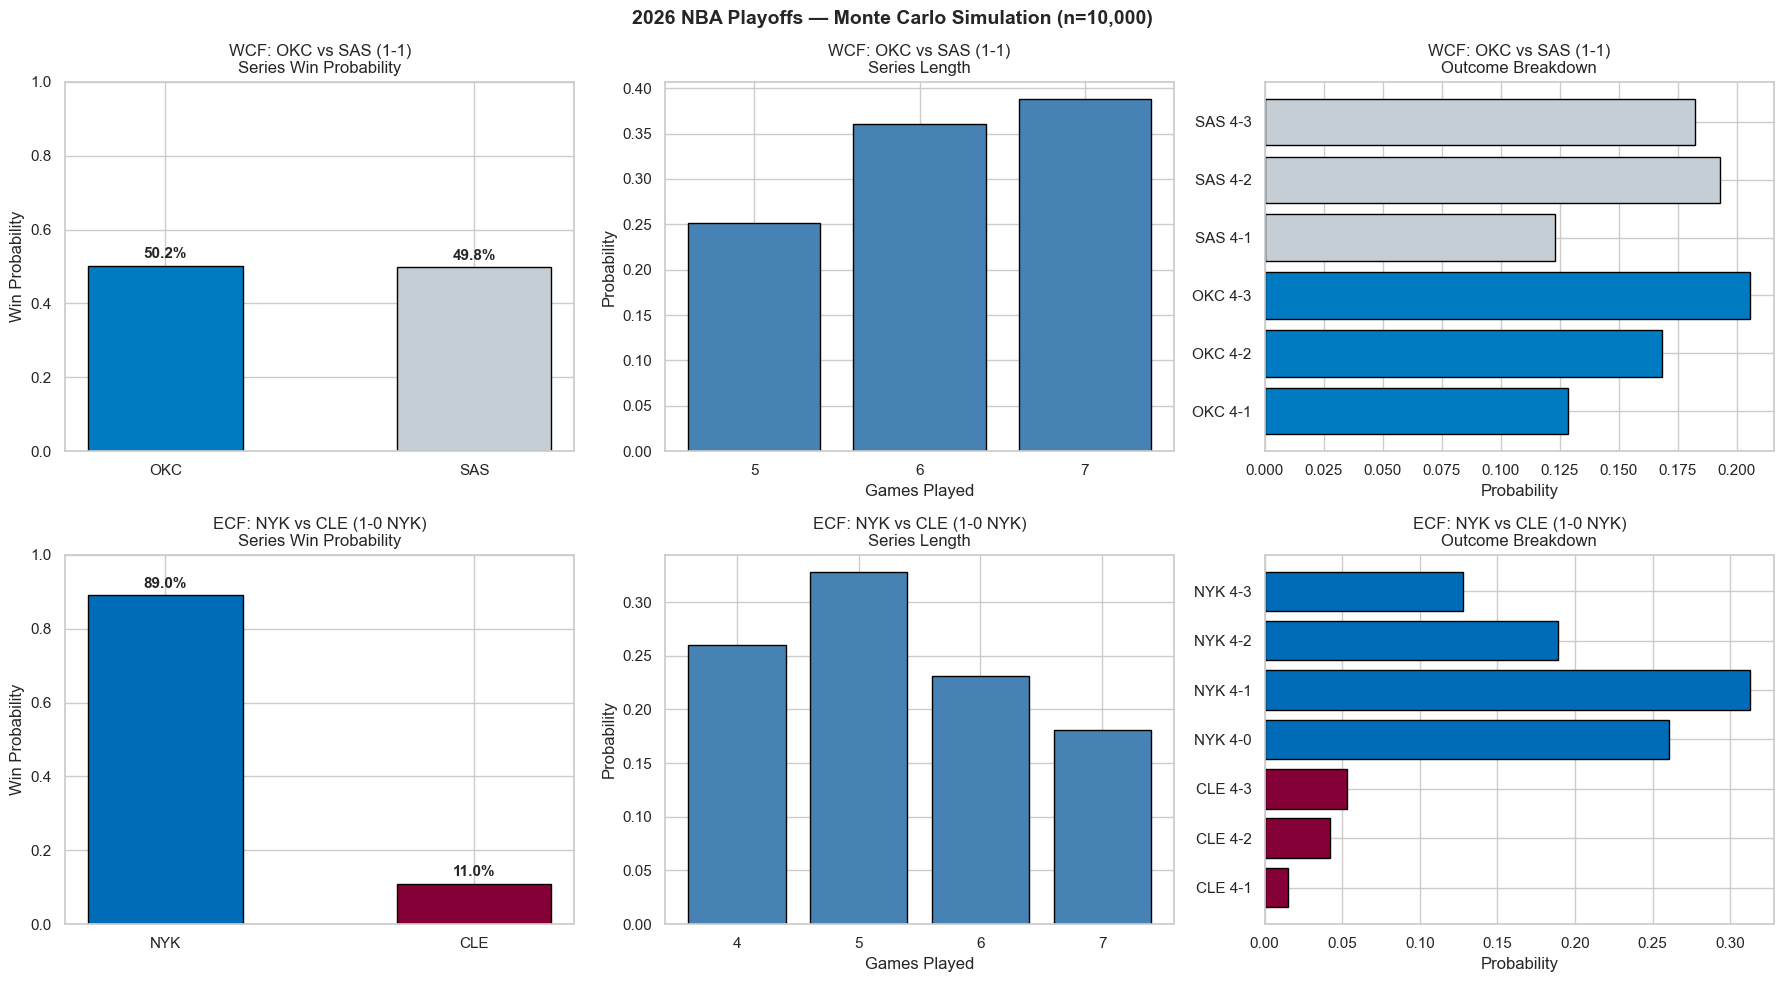

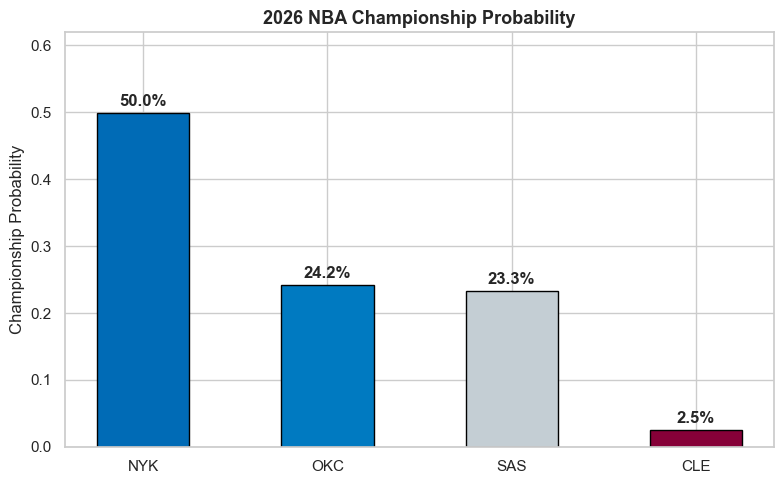

In [13]:
sns.set_theme(style='whitegrid')

TEAM_COLORS = {
    'OKC': '#007AC1', 'SAS': '#C4CED4',
    'NYK': '#006BB6', 'CLE': '#860038',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2026 NBA Playoffs — Monte Carlo Simulation (n=10,000)', fontsize=14, fontweight='bold')

def plot_series(axes_row, df, t1, t2, p_t1, title_prefix):
    p_t2 = 1 - p_t1

    # Win probability
    ax = axes_row[0]
    bars = ax.bar([t1, t2], [p_t1, p_t2],
                  color=[TEAM_COLORS[t1], TEAM_COLORS[t2]], edgecolor='black', width=0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Win Probability')
    ax.set_title(f'{title_prefix}\nSeries Win Probability')
    for bar, p in zip(bars, [p_t1, p_t2]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{p:.1%}', ha='center', fontweight='bold', fontsize=11)

    # Series length
    ax = axes_row[1]
    length_dist = df['games_played'].value_counts().sort_index()
    ax.bar(length_dist.index, length_dist.values / N_SIMS, color='steelblue', edgecolor='black')
    ax.set_xticks(sorted(df['games_played'].unique()))
    ax.set_xlabel('Games Played')
    ax.set_ylabel('Probability')
    ax.set_title(f'{title_prefix}\nSeries Length')

    # Outcome breakdown
    ax = axes_row[2]
    outcome_counts = df['outcome'].value_counts().sort_index()
    bar_colors = [TEAM_COLORS[t1] if o.startswith(t1) else TEAM_COLORS[t2]
                  for o in outcome_counts.index]
    ax.barh(outcome_counts.index, outcome_counts.values / N_SIMS,
            color=bar_colors, edgecolor='black')
    ax.set_xlabel('Probability')
    ax.set_title(f'{title_prefix}\nOutcome Breakdown')

plot_series(axes[0], wcf_df, 'OKC', 'SAS', p_okc, 'WCF: OKC vs SAS (1-1)')
plot_series(axes[1], ecf_df, 'NYK', 'CLE', p_nyk, 'ECF: NYK vs CLE (1-0 NYK)')

plt.tight_layout()
plt.savefig('../outputs/conference_finals.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Championship probability chart ──────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(8, 5))
champ = {'OKC': p_okc_champ, 'SAS': p_sas_champ, 'NYK': p_nyk_champ, 'CLE': p_cle_champ}
teams_sorted  = sorted(champ, key=lambda x: -champ[x])
probs_sorted  = [champ[t] for t in teams_sorted]
colors_sorted = [TEAM_COLORS[t] for t in teams_sorted]

bars = ax.bar(teams_sorted, probs_sorted, color=colors_sorted, edgecolor='black', width=0.5)
ax.set_ylim(0, max(probs_sorted) + 0.12)
ax.set_ylabel('Championship Probability')
ax.set_title('2026 NBA Championship Probability', fontsize=13, fontweight='bold')
for bar, p in zip(bars, probs_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{p:.1%}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/championship_probability.png', dpi=150, bbox_inches='tight')
plt.show()